# Proyek Analisis Data: Air-quality-dataset
- **Nama:** Sevilla Claudia Depari
- **Email:** sevilla.depari04@gmail.com
- **ID Dicoding:** claud89

## Menentukan Pertanyaan Bisnis

- Bagaimana perbandingan rata-rata konsentrasi PM2.5 antar stasiun pemantauan selama periode 2013-2017, serta stasiun mana yang memiliki tingkat polusi tertinggi dan terendah untuk menentukan wilayah prioritas pengendalian polusi udara?
- Bagaimana hubungan antara suhu (TEMP), curah hujan (RAIN), dan kecepatan angin (WSPM) terhadap konsentrasi PM2.5 di seluruh stasiun selama periode 2013-2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import zipfile
import os

## Data Wrangling

### Gathering Data

Pada tahap ini dilakukan pengumpulan data dan memuat 12 file CSV yang mewakili 12 stasiun pemantauan, kemudian seluruh data digabungkan menjadi satu DataFrame agar lebih mudah digunakan pada proses analisis selanjutnya.

In [2]:
with zipfile.ZipFile('data/Air-quality-dataset.zip', 'r') as zip_ref:
  zip_ref.extractall('/data/air_quality/')

files = glob.glob('/data/air_quality/**/*.csv', recursive=True)

print("Jumlah file: ", len(files))

Jumlah file:  12


In [3]:
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


Seluruh data dari masing-masing stasiun digabungkan agar analisis perbandingan antar stasiun dan analisis hubungan kondisi cuaca terhadap polusi udara dapat dilakukan secara menyeluruh sesuai pertanyaan bisnis yang telah ditentukan.

In [4]:
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong


In [5]:
df.shape

(420768, 18)

**Insight:**
- Dataset air quality ini terdiri dari 12 file csv yang merepresentasikan 12 stasiun pemantauan kualitas udara.
- Seluruh file berhasil dimuat dan digabungkan menjadi satu DataFrame untuk memudahkan analisis secara menyeluruh.
- Dataset hasil penggabungan memiliki 420.768 baris dan 18 kolom, yang menunjukkan data memiliki cakupan observasi yang cukup besar.
- Data selanjutnya siap dilakukan ke tahap Assessing Data untuk pemeriksaan kualitas data.

### Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data untuk mengidentifikasi permasalahan seperti missing value, duplicate data, inkonsistensi tipe data, serta potensi outlier sebelum memasuki tahap cleaning data.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [7]:
df.isnull().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


Berdasarkan statistik deskriptif terlihat beberapa variabel memiliki rentang nilai yang cukup lebar serta nilai maksimum yang jauh di atas kuartil ketiga, sehingga terindikasi memiliki outlier. Oleh karena itu, dilakukan pemeriksaan lebih lanjut menggunakan visualisasi boxplot.

Pada analisis outlier, variabel numerik pada dataset dikelompokkan menjadi dua, yaitu polutan udara (PM2.5, PM10, SO2, NO2, CO, O3) serta faktor cuaca (TEMP, PRESS, DEWP, RAIN, WSPM).

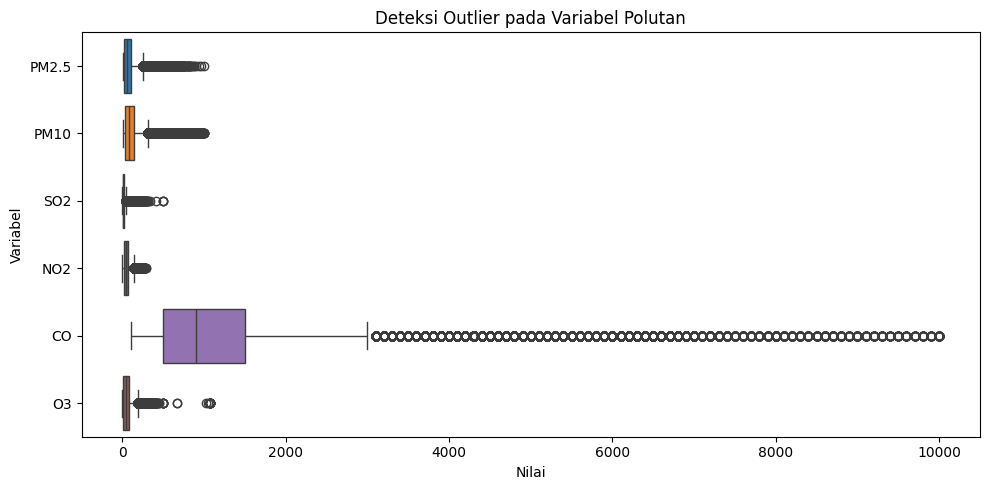

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']], orient='h')
plt.title('Deteksi Outlier pada Variabel Polutan')
plt.xlabel('Nilai')
plt.ylabel('Variabel')
plt.tight_layout()
plt.show()

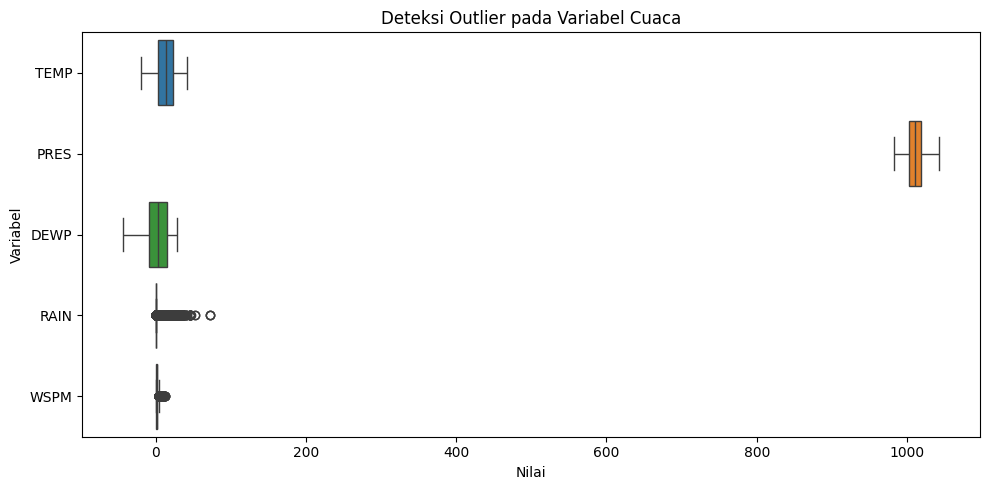

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']], orient='h')
plt.title('Deteksi Outlier pada Variabel Cuaca')
plt.xlabel('Nilai')
plt.ylabel('Variabel')
plt.tight_layout()
plt.show()

Setelah identifikasi visual menggunakan boxplot, deteksi outlier dikonfirmasi menggunakan metode IQR (Interquartile Range) pada variabel polutan dan cuaca untuk mengetahui jumlah nilai ekstrem pada masing-masing variabel.

In [12]:
cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
        'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

print("Jumlah Outlier Berdasarkan Metode IQR")
print("-"*45)

for col in cols:
  data = df[col].dropna()
  Q1 = data.quantile(0.25)
  Q3 = data.quantile(0.75)
  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = data[(data < lower) | (data > upper)]

  print(f"{col}: {len(outliers)} outlier ({len(outliers)/len(data)*100:.2f}%)")

Jumlah Outlier Berdasarkan Metode IQR
---------------------------------------------
PM2.5: 19142 outlier (4.65%)
PM10: 14658 outlier (3.54%)
SO2: 35566 outlier (8.64%)
NO2: 7021 outlier (1.72%)
CO: 28054 outlier (7.01%)
O3: 16599 outlier (4.07%)
TEMP: 0 outlier (0.00%)
PRES: 0 outlier (0.00%)
DEWP: 0 outlier (0.00%)
RAIN: 16520 outlier (3.93%)
WSPM: 23079 outlier (5.49%)


**Insight:**
- Terdapat missing values pada beberapa kolom polutan dan cuaca, serta tidak ditemukan data duplikat.
- Berdasarkan statistik deskriptif, visualisasi boxplot, dan metode IQR, teridentifikasi adanya outlier pada beberapa variabel polutan maupun variabel cuaca.
- Pada tahap cleaning data selanjutnya akan dilakukan penanganan missing values menggunakan metode imputasi sesuai karakteristik masing-masing variabel. Sementara itu, nilai outlier akan dievaluasi lebih lanjut dan tidak langsung dihapus karena nilai ekstrem pada data kualitas udara dan cuaca dapat merepresentasikan kondisi yang valid.

### Cleaning Data

Pada tahap ini dilakukan proses pembersihan data berdasarkan permasalahan yang ditemukan pada tahap assessing data. Proses cleaning meliputi penanganan missing value, evaluasi nilai outlier, serta transformasi kolom waktu menjadi format datetime agar data siap digunakan untuk analisis lanjutan.

In [13]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [14]:
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

Kolom datetime dibuat dan data diurutkan berdasarkan stasiun serta waktu agar proses interpolasi dilakukan sesuai urutan kronologis.

In [15]:
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
        'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df[num_cols] = df.groupby('station')[num_cols].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both'))

In [16]:
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

Setelah melakukan proses cleaning, dilakukan pengecekan ulang missing values untuk memastikan seluruh nilai yang hilang telah berhasil ditangani.

In [17]:
df.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

In [18]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [19]:
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong,2017-02-28 19:00:00
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong,2017-02-28 20:00:00
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong,2017-02-28 21:00:00
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong,2017-02-28 22:00:00


Preview data menunjukkan dataset telah melalui proses cleaning dan siap digunakan untuk tahap eksplorasi data berikutnya.

**Insight:**
- Kolom datetime ditambahkan sebagai gabungan year, month, day, dan hour untuk memudahkan analisis berbasis waktu, sementara kolom aslinya tetap dipertahankan agar analisis per tahun, bulan, hari, atau jam dapat dilakukan dengan lebih mudah.
- Missing values pada variabel numerik berhasil ditangani menggunakan interpolasi linear berdasarkan urutan waktu pada masing-masing stasiun. Parameter 'limit_direction='both'' digunakan agar nilai kosong di awal maupun akhir data tetap dapat terisi.
- Untuk kolom kategorikal 'wd', missing values ditangani menggunakan nilai modus karena kolom tersebut berisi arah angin. Setelah proses cleaning dilakukan, tidak terdapat lagi missing values pada dataset.
- Nilai outlier tidak dihapus karena masih dapat merepresentasikan kondisi kualitas udara dan cuaca yang valid.
- Dataset hasil cleaning siap digunakan pada tahap Exploratory Data Analysis.

## Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan eksplorasi data menggunakan rangkuman statistik, pengelompokan data, dan analisis hubungan antar variabel untuk memahami kondisi polusi udara, membandingkan kondisi antar stasiun pemantauan, serta mengidentifikasi keterkaitan faktor cuaca dengan konsentrasi PM2.5. Hasil eksplorasi ini akan digunakan untuk menjawab pertanyaan bisnis yang telah ditentukan.

### Explorasi Awal Data

In [20]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.839718,104.910268,15.913090,50.599018,1235.682649,57.237872,13.531692,1010.753337,2.482421,0.064428,1.730034,2015-03-01 11:30:00.000001024
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 11:30:00
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.950217,92.431422,21.896609,35.171921,1161.790893,57.135195,11.437867,10.474302,13.797675,0.820638,1.246674,NaN


Statistik deskriptif ditampilkan kembali pada tahap EDA untuk memahami karakteristik umum data setelah proses cleaning, seperti nilai rata-rata data, sebaran data, serta rentang masing-masing variabel yang akan digunakan pada analisis lanjutan.

In [21]:
print("Jumlah stasiun: ", df['station'].nunique())
print("Nama stasiun: ", df['station'].unique())

Jumlah stasiun:  12
Nama stasiun:  ['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']


In [22]:
print("Periode data: ", df['datetime'].min(), df['datetime'].max())

Periode data:  2013-03-01 00:00:00 2017-02-28 23:00:00


Dataset terdiri dari 12 stasiun pemantauan dengan periode pengamatan Maret 2013 hingga Februari 2017. Statistik deskriptif menunjukkan variasi nilai polutan dan faktor cuaca yang cukup beragam, sehingga data siap digunakan untuk analisis lebih lanjut menjawab pertanyaan bisnis.

### Perbandingan Rata-rata Konsentrasi PM2.5 antar Stasiun Pemantauan

In [23]:
pm25_station = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).round(2)
pm25_station

station
Dongsi           86.14
Nongzhanguan     85.08
Wanshouxigong    85.07
Gucheng          84.07
Wanliu           83.47
Guanyuan         82.90
Aotizhongxin     82.54
Tiantan          82.03
Shunyi           79.44
Changping        70.99
Huairou          69.50
Dingling         66.85
Name: PM2.5, dtype: float64

In [24]:
df.groupby('station')['PM2.5'].agg(['mean', 'median', 'min', 'max']).round(2)

,mean,median,min,max
station,,,,
Aotizhongxin,82.54,58.0,3.0,898.0
Changping,70.99,46.0,2.0,882.0
Dingling,66.85,41.0,3.0,881.0
Dongsi,86.14,61.0,3.0,737.0
Guanyuan,82.90,59.0,2.0,680.0
Gucheng,84.07,60.0,2.0,770.0
Huairou,69.50,47.0,2.0,762.0
Nongzhanguan,85.08,59.0,2.0,844.0
Shunyi,79.44,55.0,2.0,941.0


In [25]:
print("Stasiun dengan PM2.5 tertinggi: ")
print(pm25_station.idxmax(), "-", pm25_station.max())

print("\nStasiun dengan PM2.5 terendah: ")
print(pm25_station.idxmin(), "-", pm25_station.min())

Stasiun dengan PM2.5 tertinggi: 
Dongsi - 86.14

Stasiun dengan PM2.5 terendah: 
Dingling - 66.85


### Hubungan Faktor Cuaca Terhadap Konsentrasi PM2.5 di Seluruh Stasiun

In [26]:
corr_pm25 = df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()['PM2.5'].sort_values(ascending=False)
corr_pm25

PM2.5    1.000000
DEWP     0.113045
PRES     0.019862
RAIN    -0.014452
TEMP    -0.131607
WSPM    -0.271425
Name: PM2.5, dtype: float64

In [27]:
df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

,PM2.5,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.000000,-0.131607,0.019862,0.113045,-0.014452,-0.271425
TEMP,-0.131607,1.000000,-0.813312,0.820247,0.037647,0.032601
PRES,0.019862,-0.813312,1.000000,-0.750271,-0.060952,0.065400
DEWP,0.113045,0.820247,-0.750271,1.000000,0.086259,-0.296771
RAIN,-0.014452,0.037647,-0.060952,0.086259,1.000000,0.020975
WSPM,-0.271425,0.032601,0.065400,-0.296771,0.020975,1.000000


In [28]:
factor = corr_pm25.drop('PM2.5').abs().idxmax()
value = corr_pm25.drop('PM2.5').abs().max()

print("Faktor Cuaca dengan hubungan terkuat: ", factor)
print("Nilai Korelasi Absolut: ", round(value,3))

Faktor Cuaca dengan hubungan terkuat:  WSPM
Nilai Korelasi Absolut:  0.271


In [29]:
df.groupby(pd.cut(df['RAIN'],
                  bins=[-0.1,0,5,20,100],
                  labels=['No Rain', 'Light', 'Moderate', 'Heavy']),
           observed=False
)['PM2.5'].mean().round(2)

RAIN
No Rain     80.56
Light       61.94
Moderate    67.49
Heavy       69.06
Name: PM2.5, dtype: float64

In [30]:
df.groupby(pd.cut(df['RAIN'],
                  bins=[-0.1,0,5,20,100],
                  labels=['No Rain', 'Light', 'Moderate', 'Heavy']),
           observed=False
)['PM2.5'].count()

RAIN
No Rain     404241
Light        15369
Moderate       992
Heavy          166
Name: PM2.5, dtype: int64

Analisis rata-rata PM2.5 digunakan untuk melihat pola hubungan antara curah hujan dan polusi udara. Sementara itu, jumlah data pada tiap kategori curah hujan digunakan sebagai informasi tambahan untuk memahami distribusi data yang tidak merata, yang berpotensi memengaruhi nilai rata-rata yang dihasilkan.

In [31]:
df.groupby(pd.cut(df['WSPM'],
                  bins=[0,1,2,4,10],
                  labels=['Low', 'Medium', 'High', 'Very High']),
           observed=False
)['PM2.5'].mean().round(2)

WSPM
Low          101.46
Medium        84.64
High          53.73
Very High     28.72
Name: PM2.5, dtype: float64

**Insight:**
- Terdapat perbedaan rata-rata konsentrasi PM2.5 antar stasiun pemantauan, yang menunjukkan tingkat polusi udara tidak merata pada setiap wilayah pengamatan.
- Stasiun dengan nilai rata-rata PM2.5 tertinggi, yaitu Dongsi (86.14) dapat menjadi prioritas pengendalian polusi udara, sedangkan stasiun dengan nilai terendah, yaitu Dingling (66.85) menunjukkan kualitas udara relatif lebih baik.
- Berdasarkan analisis korelasi, kecepatan angin (WSPM) memiliki hubungan paling kuat terhadap PM2.5 dengan nilai korelasi -0.27. Nilai negatif ini menunjukkan bahwa semakin tinggi kecepatan angin, konsentrasi PM2.5 cenderung menurun. Hasil pengelompokan kecepatan angin memperkuat temuan tersebut, di mana rata-rata PM2.5 menurun dari 101.46 pada kategori Low menjadi 28.72 pada kategori Very High. Hal ini mengindikasikan bahwa angin berperan dalam menyebarkan polutan di udara.
- Pada analisis lebih lanjut menggunakan pengelompokan intensitas hujan, curah hujan menunjukkan bahwa konsentrasi PM2.5 cenderung lebih tinggi saat tidak hujan dibanding saat terjadi hujan. Hal ini mengindikasikan bahwa meskipun hubungan linear tidak kuat, curah hujan tetap berperan dalam menurunkan polusi udara.

## Visualization & Explanatory Analysis

Pada tahap ini dilakukan visualisasi data untuk memperjelas hasil eksplorasi sebelumnya serta menjawab pertanyaan bisnis yang telah ditentukan. Visualisasi digunakan untuk menunjukkan perbandingan tingkat polusi udara antar stasiun pemantauan dan hubungan antara faktor cuaca dengan konsentrasi PM2.5 agar insight lebih mudah dipahami.

### Pertanyaan 1:

Bagaimana perbandingan rata-rata konsentrasi PM2.5 antar stasiun pemantauan selama periode 2013-2017, serta stasiun mana yang memiliki tingkat polusi tertinggi dan terendah untuk menentukan wilayah prioritas pengendalian polusi udara?

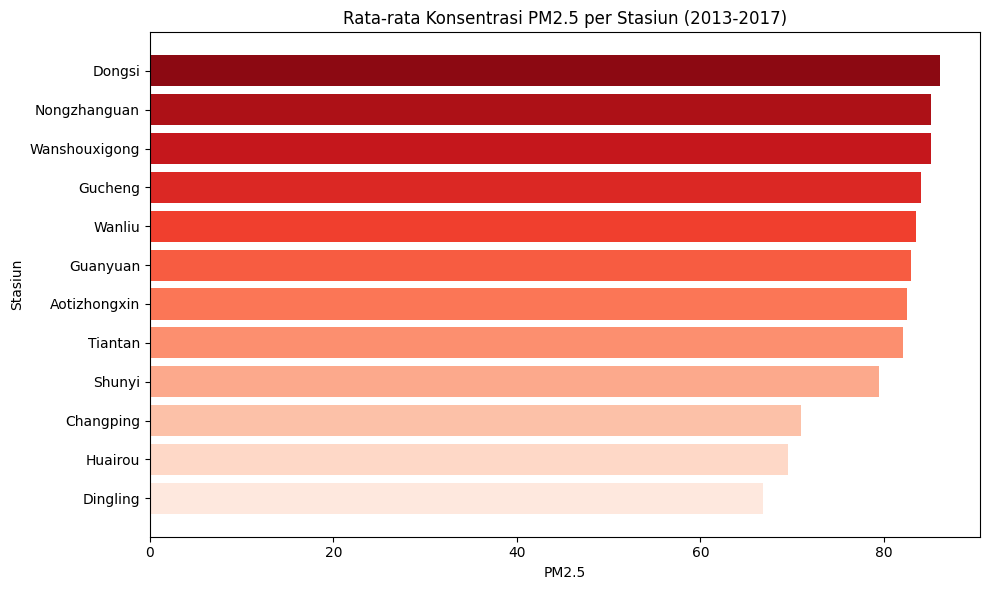

In [32]:
pm25_station = df.groupby('station')['PM2.5'].mean().sort_values(ascending=True)

plt.figure(figsize=(10,6))

colors = sns.color_palette("Reds", n_colors=len(pm25_station))

plt.barh(pm25_station.index, pm25_station.values, color=colors)

plt.title('Rata-rata Konsentrasi PM2.5 per Stasiun (2013-2017)')
plt.xlabel('PM2.5')
plt.ylabel('Stasiun')
plt.tight_layout()
plt.show()

**Explanatory Analysis:**

Grafik menunjukkan bahwa adanya perbedaan rata-rata konsentrasi PM2.5 antar stasiun pemantauan selama periode 2013-2017. Stasiun **Dongsi** memiliki nilai rata-rata PM2.5 tertinggi, sedangkan stasiun **Dingling** memiliki nilai terendah.

Perbedaan ini mengindikasikan bahwa tingkat polusi udara tidak merata di setiap stasiun pemantauan. Stasiun dengan nilai PM2.5 lebih tinggi menunjukkan kondisi pencemaran udara yang relatif lebih buruk, sehingga wilayah tersebut dapat menjadi prioritas dalam upaya pengendalian polusi udara.

Selain itu, sebagian besar stasiun lainnya memiliki nilai yang relatif berdekatan. Hal ini menunjukkan bahwa meskipun terdapat variasi antar wilayah, kondisi polusi udara secara umum cenderung serupa di beberapa lokasi, dengan pengecualian pada stasiun tertentu yang memiliki nilai lebih ekstrem.

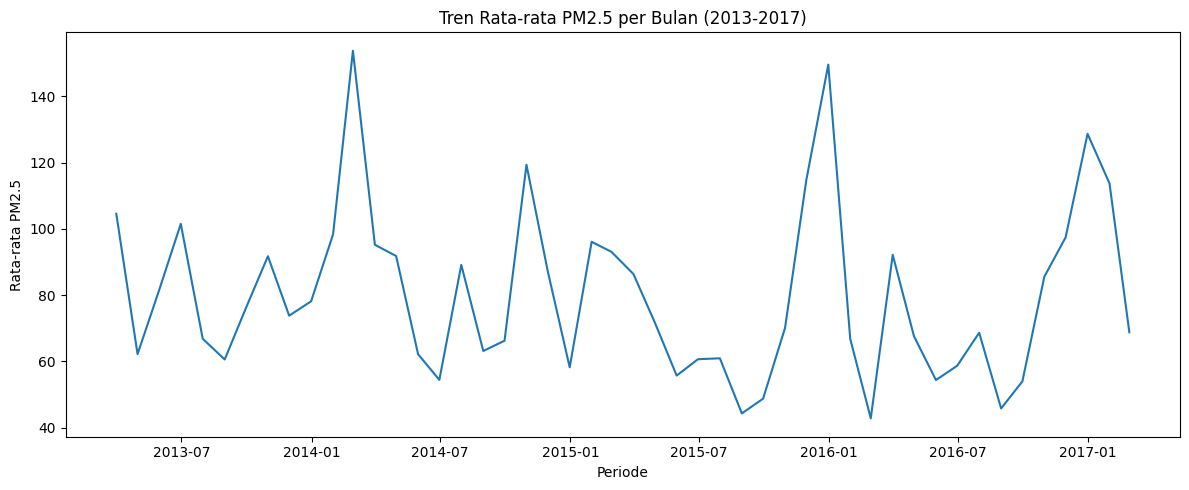

In [33]:
monthly_pm25 = df.resample('ME', on='datetime')['PM2.5'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_pm25.index, monthly_pm25.values)

plt.title('Tren Rata-rata PM2.5 per Bulan (2013-2017)')
plt.xlabel('Periode')
plt.ylabel('Rata-rata PM2.5')
plt.tight_layout()
plt.show()

**Explanatory Analysis:**

Grafik menunjukkan tren rata-rata konsentrasi PM2.5 bulanan selama periode 2013-2017 yang bersifat fluktuatif. Terlihat adanya beberapa periode dengan lonjakan nilai PM2.5 yang cukup tinggi, serta periode lain dengan penuruan yang signifikan.

Pola ini mengindikasikan bahwa tingkat polusi udara tidak bersifat konstan, melainkan berubah dari waktu ke waktu. Fluktuasi tersebut kemungkinan berkaitan dengan faktor musiman, kondisi cuaca, serta aktivitas manusia pada periode tertentu.

Secara umum tidak terlihat peningkatan atau penurunan yang konsisten dalam jangka panjang, namun terdapat variasi yang cukup signifikan pada waktu-waktu tertentu.

### Pertanyaan 2:

Bagaimana hubungan antara suhu (TEMP), curah hujan (RAIN), dan kecepatan angin (WSPM) terhadap konsentrasi PM2.5 di seluruh stasiun selama periode 2013-2017?

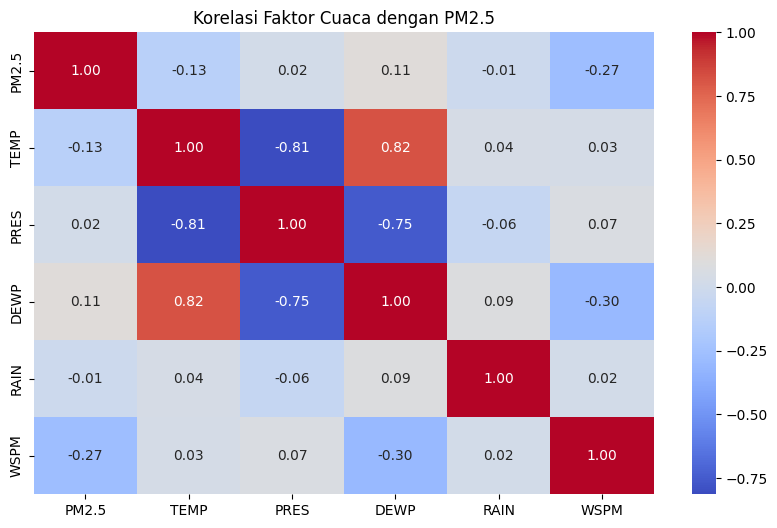

In [34]:
corr = df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Korelasi Faktor Cuaca dengan PM2.5')
plt.show()

**Explanatory Analysis:**

Heatmap menunjukkan bahwa kecepatan angin (WSPM) memiliki hubungan negatif paling kuat terhadap PM2.5 dibanding variabel cuaca lainnya, dengan nilai korelasi sekitar -0.27. Hal ini menunjukkan bahwa peningkatan kecepatan angin cenderung diikuti penurunan konsentrasi PM2.5.

Sementara itu, suhu (TEMP) dengan nilai sekitar -0.13 dan curah hujan (RAIN) dengan nilai sekitar -0.01 menunjukkan hubungan yang lebih lemah terhadap PM2.5. Hal ini mengindikasikan bahwa dibandingkan faktor cuaca lainnya, kecepatan angin memiliki keterkaitan paling kuat dengan penurunan tingkat polusi udara.

Meskipun variabel DEWP memiliki nilai korelasi yang sedikit lebih tinggi dibandingkan curah hujan, analisis difokuskan pada variabel yang telah ditentukan dalam pertanyaan bisnis, yaitu suhu, curah hujan, dan kecepatan angin.

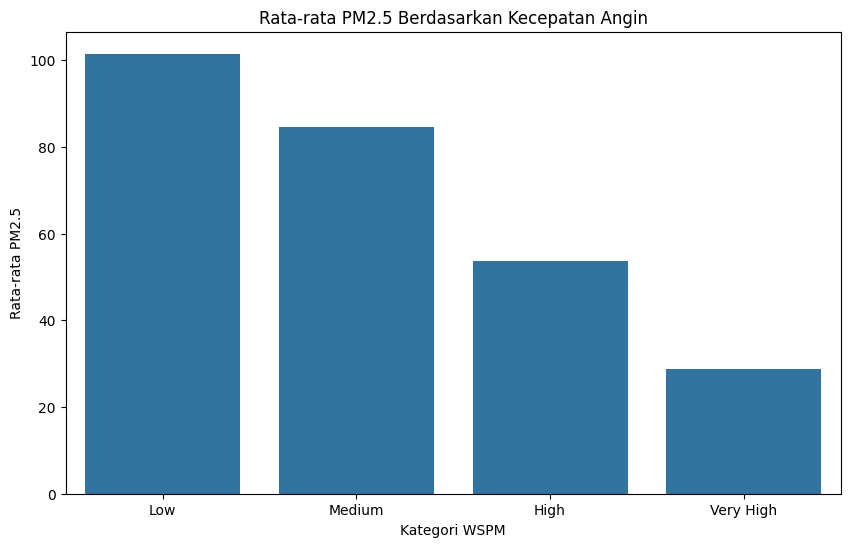

In [35]:
wspm_cat = df.groupby(
    pd.cut(df['WSPM'],
           bins=[0,1,2,4,10],
           labels=['Low', 'Medium', 'High', 'Very High']),
    observed=False
)['PM2.5'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=wspm_cat.index, y=wspm_cat.values)
plt.title('Rata-rata PM2.5 Berdasarkan Kecepatan Angin')
plt.xlabel('Kategori WSPM')
plt.ylabel('Rata-rata PM2.5')
plt.show()

**Explanatory Analysis:**

Grafik menunjukkan bahwa rata-rata konsentrasi PM2.5 menurun secara konsisten seiring dengan meningkatnya kecepatan angin. Pada kategori kecepatan rendah (Low), nilai PM2.5 berada pada tingkat tertinggi, sedangkan pada kategori sangat tinggi (Very High) nilai PM2.5 mencapai nilai terendah.

Pola penurunan yang jelas ini mengindikasikan bahwa kecepatan angin memiliki hubungan kuat dalam menurunkan konsentrasi polusi udara. Semakin tinggi kecepatan angin, semakin besar kemampuan angin dalam menyebarkan partikel polutan, sehingga konsentrasi PM2.5 di udara menjadi lebih rendah.

Hal ini memperkuat temuan sebelumnya dari analisis korelasi yang menunjukkan hubungan negatif antara kecepatan angin dengan PM2.5, serta menegaskan bahwa kecepatan angin merupakan faktor cuaca dengan keterkaitan paling kuat terhadap tingkat polusi udara.

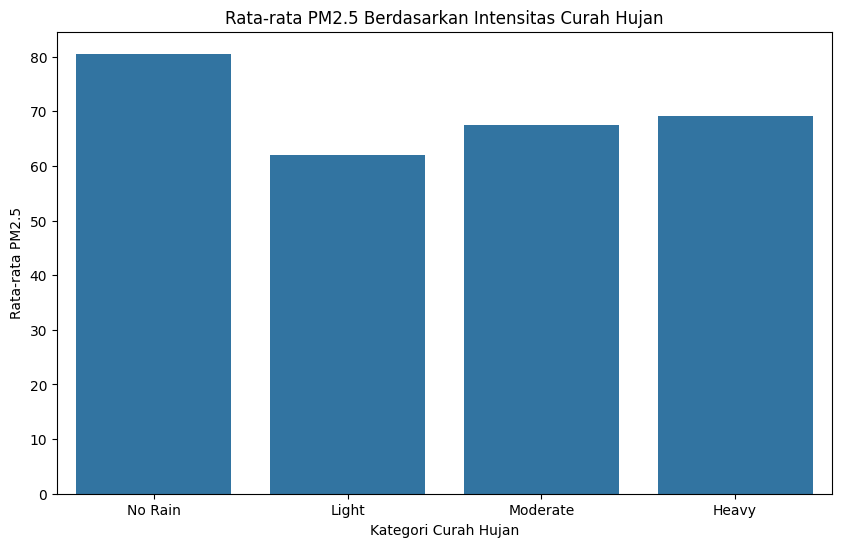

In [36]:
rain_cat = df.groupby(
    pd.cut(df['RAIN'],
           bins=[-0.1,0,5,20,100],
           labels=['No Rain', 'Light', 'Moderate', 'Heavy']),
    observed=False
)['PM2.5'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=rain_cat.index, y=rain_cat.values)
plt.title('Rata-rata PM2.5 Berdasarkan Intensitas Curah Hujan')
plt.xlabel('Kategori Curah Hujan')
plt.ylabel('Rata-rata PM2.5')
plt.show()

**Explanatory Analysis:**

Grafik menunjukkan bahwa rata-rata PM2.5 paling tinggi terjadi pada kondisi tanpa hujan. Saat terjadi hujan, rata-rata PM2.5 cenderung lebih rendah, terutama pada kategori hujan ringan.

Namun, perlu diperhatikan bahwa distribusi data pada setiap kategori curah hujan tidak merata, sehingga nilai rata-rata pada kategori dengan jumlah data yang lebih sedikit kurang representatif.

Hal ini mengindikasikan bahwa curah hujan berperan dalam membantu menurunkan konsentrasi polusi udara, meskipun pola penurunannya tidak sepenuhnya linear pada setiap kategori intensitas hujan, yang menunjukkan adanya pengaruh faktor lain terhadap konsentrasi PM2.5.

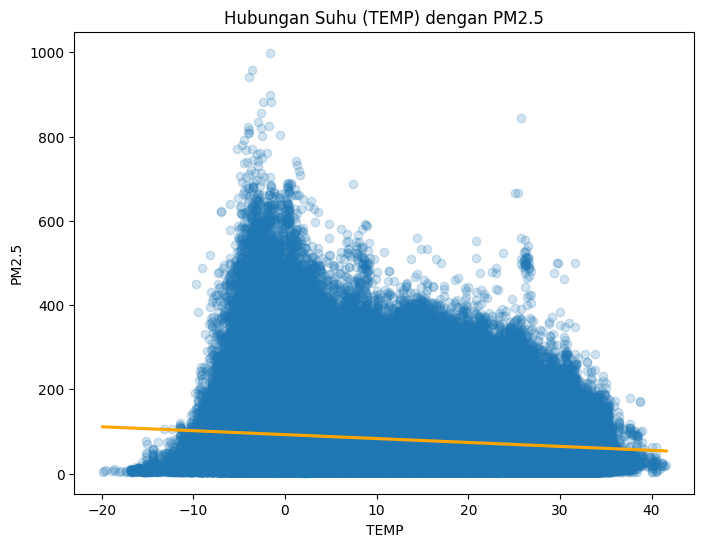

In [37]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='TEMP',
    y='PM2.5',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'orange'}
)

plt.title('Hubungan Suhu (TEMP) dengan PM2.5')
plt.xlabel('TEMP')
plt.ylabel('PM2.5')
plt.show()

**Explanatory Analysis:**

Grafik menunjukkan bahwa hubungan antara suhu (TEMP) dan konsentrasi PM2.5 cenderung lemah. Hal ini terlihat dari sebaran data yang cukup luas dan tidak membentuk pola yang jelas, serta garis tren yang sedikit menurun.

Meskipun terdapat kecendrungan hubungan negatif, di mana peningkatan suhu diikuti dengan penurunan konsentrasi PM2.5, pengaruhnya relatif kecil dibandingkan faktor cuaca lainnya.

Hal ini menunjukkan bahwa suhu bukan merupakan faktor utama yang memengaruhi perubahan konsentrasi polusi udara dalam dataset ini.

**Insight:**
- Terdapat perbedaan rata-rata konsentrasi PM2.5 antar stasiun pemantauan, yang menunjukkan bahwa tingkat polusi udara tidak merata di setiap wilayah. Stasiun Dongsi memiliki nilai tertinggi, sedangkan Dingling terendah, sehingga wilayah dengan tingkat polusi lebih tinggi dapat menjadi prioritas dalam pengendalian polusi udara.
- Dari tren bulanan, terlihat bahwa konsentrasi PM2.5 cenderung naik-turun (fluktuatif) dan tidak menunjukkan pola peningkatan atau penurunan yang konsisten, yang mengindikasikan bahwa polusi udara bberkaitan dengan berbagai faktor yang berubah-ubah dari waktu ke waktu.
- Kecepatan angin (WSPM) memiliki hubungan negatif paling kuat terhadap PM2.5, di mana semakin tinggi kecepatan angin, konsentrasi PM2.5 cenderung menurun. Ini menunjukkan bahwa angin membantu menyebarkan polutan di udara.
- Curah hujan (RAIN) menunjukkan bahwa PM2.5 cenderung lebih tinggi saat tidak hujan dibandingkan saat hujan. Namun, pola penurunannya tidak sepenuhnya konsisten, kemungkinan dipengaruhi faktor lain seperti kecepatan angin atau distribusi data yang tidak merata di tiap kategori hujan.
- Suhu (TEMP) memiliki hubungan yang relatif lemah dengan PM2.5, dibandingkan faktor cuaca lainnya.

## Analisis Lanjutan (Opsional)

Pada tahap ini dilakukan analisis lanjutan menggunakan teknik clustering sederhana (binning) untuk mengelompokkan nilai PM2.5 ke dalam beberapa kategori tingkat kualitas udara. Pengelompokan ini bertujuan untuk mempermudah interpretasi tingkat polusi udara serta melihat distribusi kualitas udara pada masing-masing stasiun pemantauan.

## Clustering Tingkat Polusi Udara

Analisis lanjutan dilakukan dengan mengelompokkan konsentrasi PM2.5 ke dalam beberapa kategori tingkat kualitas udara menggunakan teknik binning. Pendekatan ini bertujuan untuk mempermudah interpretasi data serta mengidentifikasi tingkat keparahan polusi udara pada masing-masing stasiun pemantauan.

## Clustering Stasiun Berdasarkan Rata-rata PM2.5

In [38]:
station_pm25 = df.groupby('station')['PM2.5'].mean().reset_index()

station_pm25['Cluster'] = station_pm25['PM2.5'].apply(
    lambda x: 'Tinggi' if x >= 80 else 'Sedang' if x >= 72 else 'Rendah'
)

station_pm25.sort_values('PM2.5', ascending=False)

,station,PM2.5,Cluster
3,Dongsi,86.144243,Tinggi
7,Nongzhanguan,85.079472,Tinggi
11,Wanshouxigong,85.067548,Tinggi
5,Gucheng,84.074802,Tinggi
10,Wanliu,83.467612,Tinggi
4,Guanyuan,82.897522,Tinggi
0,Aotizhongxin,82.540623,Tinggi
9,Tiantan,82.033097,Tinggi
8,Shunyi,79.437962,Sedang
1,Changping,70.986438,Rendah


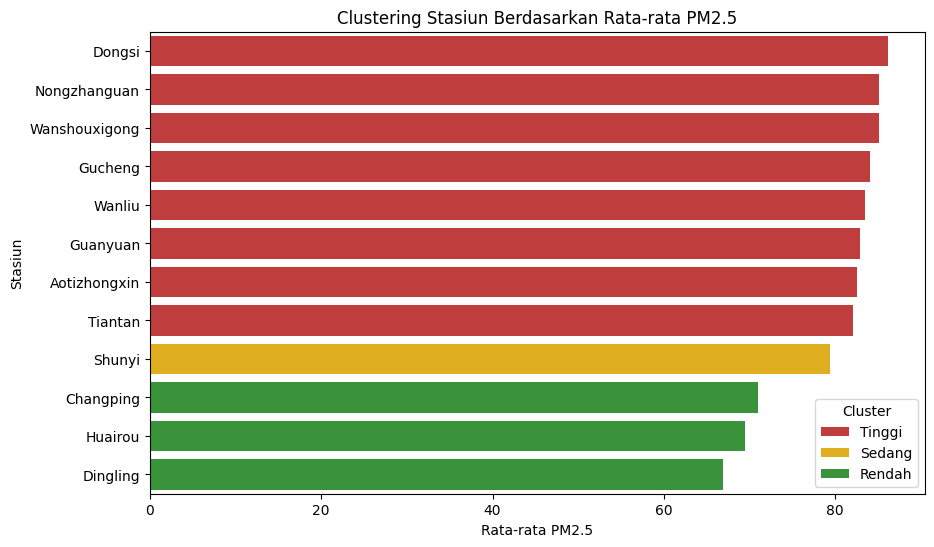

In [39]:
plt.figure(figsize=(10,6))

palette = {
    'Tinggi': '#d62728',
    'Sedang': '#ffbf00',
    'Rendah': '#2ca02c'
}

sns.barplot(
    data=station_pm25.sort_values('PM2.5', ascending=False),
    x='PM2.5',
    y='station',
    hue='Cluster',
    dodge=False,
    palette=palette
)

plt.title('Clustering Stasiun Berdasarkan Rata-rata PM2.5')
plt.xlabel('Rata-rata PM2.5')
plt.ylabel('Stasiun')
plt.show()

**Teknik Yang Dipakai**
- Teknik yang dipakai adalah clustering manual karena lebih sederhana dan mudah diinterpretasikan dalam mengelompokkan stasiun berdasarkan tingkat polusi udara.
- Pengelompokan dilakukan dengan membagi nilai rata-rata PM2.5 ke dalam kategori tertentu, yaitu tinggi, sedang, dan rendah.
- Metode ini dipilih karena sesuai dengan tujuan analisis, yaitu untuk membandingkan kondisi antar stasiun dan menentukan wilayah yang menjadi prioritas dalam pengendalian polusi udara.

**Insight**

- Hasil clustering menunjukkan bahwa terdapat perbedaan tingkat polusi udara antar stasiun pemantauan. Beberapa stasiun seperti Dongsi, Nongzhanguan, dan Wanshouxigong termasuk dalam kategori polusi tinggi, sehingga perlu mendapat perhatian lebih dalam pengendalian kualitas udara.
- Stasiun seperti Dingling, Huairou, Changping berada pada kategori polusi rendah, yang menunjukkan kondisi udara relatif lebih baik dibanding stasiun lainnya.
- Stasiun dengan kategori Sedang berada di antara keduanya, yang menunjukkan bahwa tingkat polusi di wilayah tersebut masih perlu dipantau agar tidak meningkat ke kategori yang lebih tinggi.
- Hasil ini menunjukkan bahwa distribusi polusi udara tidak merata antar wilayah, sehingga kebijakan pengendalian polusi dapat difokuskan pada lokasi dengan tingkat polusi yang lebih tinggi.

## Clustering Kategori Kualitas Udara Berdasarkan PM2.5

In [40]:
df['PM2.5_Category'] = pd.cut(
    df['PM2.5'],
    bins=[0, 35, 75, 115, 150, 1000],
    labels=['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
)

pm25_cat = df['PM2.5_Category'].value_counts().sort_index()
pm25_cat

PM2.5_Category
Good              156965
Moderate           99415
Unhealthy          65131
Very Unhealthy     35397
Hazardous          63860
Name: count, dtype: int64

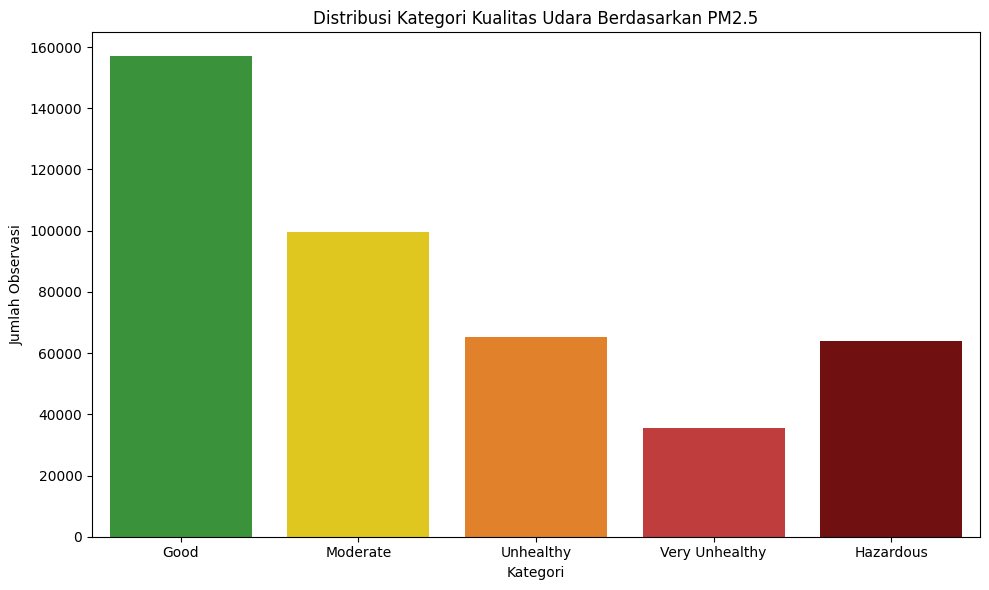

In [41]:
plt.figure(figsize=(10,6))

palette = {
    'Good': '#2ca02c',
    'Moderate': '#ffdf00',
    'Unhealthy': '#ff7f0e',
    'Very Unhealthy': '#d62728',
    'Hazardous': '#800000'
}

sns.barplot(
    x=pm25_cat.index,
    y=pm25_cat.values,
    hue=pm25_cat.index,
    palette=palette,
    legend=False
)

plt.title('Distribusi Kategori Kualitas Udara Berdasarkan PM2.5')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Observasi')
plt.tight_layout()
plt.show()

**Teknik Yang Dipakai**
- Teknik yang dipakai adalah clustering menggunakan binning (pd.cut) karena efektif untuk mengelompokkan nilai PM2.5 ke dalam kategori kualitas udara.
- Pengelompokan ke dalam kategori seperti Good hingga Hazardous membantu dalam menyederhanakan data numerik menjadi informasi yang lebih mudah dipahami, terutama dalam konteks kualitas udara.
- Metode ini juga sesuai dengan tujuan analisis, yaitu untuk melihat distribusi tingkat polusi udara tanpa menggunakan algoritma machine learning.

**Insight**

- Berdasarkan hasil pengelompokan, sebagian besar data berada pada kategori Good dan Moderate, yang menunjukkan bahwa kualitas udara pada periode pengamatan umumnya berada pada kondisi relatif baik hingga sedang.
- Meskipun demikian, masih terdapat sejumlah data yang masuk ke dalam kategori Unhealthy, Very Unhealthy, hingga Hazardous, yang menunjukkan bahwa pada waktu tertentu kondisi polusi udara yang cukup tinggi dan berpotensi membahayakan kesehatan.
- Hal ini menunjukkan bahwa kualitas udara bersifat fluktuatif, di mana pada kondisi tertentu dapat berada pada tingkat yang aman, namun pada kondisi lain dapat meningkat menjadi tidak sehat.
- Dengan adanya pengelompokan ini, distribusi tingkat kualitas udara dapat terlihat lebih jelas dibandingkan hanya menggunakan nilai PM2.5 secara langsung.

## Conclusion

- Conclution pertanyaan 1

Terdapat perbedaan rata-rata konsentrasi PM2.5 antar stasiun pemantauan selama periode 2013-2017, yang menunjukkan bahwa tingkat polusi udara tidak merata di setiap wilayah. Stasiun Dongsi memiliki rata-rata PM2.5 tertinggi, sedangkan Dingling terendah. Hal ini menunjukkan bahwa beberapa wilayah memerlukan perhatian lebih besar dalam upaya pengendalian polusi udara.
- Conclution pertanyaan 2

Faktor cuaca memiliki hubungan yang berbeda terhadap konsentrasi PM2.5. Kecepatan angin (WSPM) menunjukkan hubungan negatif paling jelas, di mana peningkatan kecepatan angin cenderung diikuti penurunan PM2.5. Curah hujan juga menunjukkan kecenderungan menurunkan PM2.5 dibanding saat tidak hujan, sedangkan suhu (TEMP) memiliki hubungan yang relatif lebih lemah.

## Recommendation

1. Prioritas Pengendalian di Wilayah dengan Polusi Tinggi

Fokuskan kebijakan pengendalian emisi, pemantauan kualitas udara, dan evaluasi sumber polusi pada stasiun dengan rata-rata PM2.5 tertinggi seperti Dongsi dan wilayah sejenisnya.

2. Tingkatkan Sistem Peringatan Dini Berbasis Cuaca

Manfaatkann informasi cuaca, khusunya saat kecepatan angin rendah dan tidak terjadi hujan, sebagai indikator peningkatan risiko polusi udara untuk mendukung sistem peringatan dini masyarakat.

3. Lakukan Monitoring Kualitas Udara Secara Berkala Antar Wilayah

Lakukan pemantauan kualitas udara secara rutin pada seluruh stasiun pemantauan, mengingat kondisi polusi udara bersifat fluktuatif dan dapat berubah seiring waktu maupun perbedaan wilayah.